<a href="https://colab.research.google.com/github/NelvaAdalit/Machine-Learning-SIS420-Datasets/blob/main/08_Breast_Cancer_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 🧬 Dataset 08: Breast Cancer Wisconsin (Original)

## 📋 Diccionario de Datos (¿Qué es cada columna?)
Este dataset clasifica tumores como **Benignos (2)** o **Malignos (4)** basándose en características celulares:
1.  **Sample Code Number**: ID del paciente (Se eliminará).
2.  **Clump Thickness**: Grosor del grupo celular (1-10).
3.  **Uniformity of Cell Size**: Uniformidad del tamaño celular (1-10).
4.  **Uniformity of Cell Shape**: Uniformidad de la forma celular (1-10).
5.  **Marginal Adhesion**: Adhesión marginal (1-10).
6.  **Single Epithelial Cell Size**: Tamaño de la célula epitelial única (1-10).
7.  **Bare Nuclei**: Núcleos desnudos (1-10). **Contiene valores faltantes '?'**.
8.  **Bland Chromatin**: Cromatina blanda (1-10).
9.  **Normal Nucleoli**: Nucléolos normales (1-10).
10. **Mitoses**: Mitosis (1-10).
11. **Class**: Objetivo (2 = Benigno, 4 = Maligno).

---
*Preparación realizada para la Primera Parte del Examen Parcial.*

In [1]:
# ==============================================================================
# 1. CONEXIÓN Y LIBRERÍAS
# ==============================================================================
from google.colab import drive
drive.mount('/content/gdrive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# CRÍTICO: Permitir que se vean TODAS las columnas sin recortes (...)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("Librerías cargadas y configuración visual activa.")

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Librerías cargadas y configuración visual activa.


In [2]:
# ==============================================================================
# 2. CARGA Y ASIGNACIÓN DE NOMBRES
# ==============================================================================
columnas = [
    'Sample_code_number', 'Clump_Thickness', 'Uniformity_Cell_Size',
    'Uniformity_Cell_Shape', 'Marginal_Adhesion', 'Single_Epithelial_Cell_SIZE',
    'Bare_Nuclei', 'Bland_Chromatin', 'Normal_Nucleoli', 'Mitoses', 'Class'
]

ruta_cancer = '/content/gdrive/MyDrive/Machine-Learning-SIS420-Datasets/08_Breast Cancer/breast-cancer-wisconsin.data'

# Cargamos tratando el '?' como NaN real
df = pd.read_csv(ruta_cancer, names=columnas, na_values='?')

# Eliminamos el ID del paciente (No tiene valor matemático)
df = df.drop('Sample_code_number', axis=1)

print("="*70)
print(f"DATASET BREAST CANCER CARGADO: {df.shape[0]} filas y {df.shape[1]} columnas")
print("="*70)
display(df.head(3))

DATASET BREAST CANCER CARGADO: 699 filas y 10 columnas


,Clump_Thickness,Uniformity_Cell_Size,Uniformity_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_SIZE,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
0,5,1,1,1,2,1.0,3,1,1,2
1,5,4,4,5,7,10.0,3,2,1,2
2,3,1,1,1,2,2.0,3,1,1,2


In [3]:
# ==============================================================================
# 3. ANTES Y DESPUÉS: LIMPIEZA RIGUROSA Y CODIFICACIÓN (50 FILAS)
# ==============================================================================
print("="*80)
print(" FASE 2: TRANSFORMACIÓN DE DIAGNÓSTICO Y LIMPIEZA DE NULOS '?'")
print("="*80)

# Configuramos visualización para auditoría exigida
pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', None)

# ------------------------------------------------------------------------------
# 1. ANTES: Datos originales con símbolos '?' y etiquetas 2/4
# ------------------------------------------------------------------------------
print("\n🔴 [ANTES] Datos originales (Class: 2=Benigno, 4=Maligno):")
print("Observe los valores '?' en 'Bare_Nuclei' que impiden cálculos matemáticos.")
display(df.head(50))

# --- PROCESO TÉCNICO DE LIMPIEZA PROFESIONAL ---

# PASO A: Conversión Forzada a Numérico
# Esto transforma los '?' en NaNs reales de inmediato para poder operar
df['Bare_Nuclei'] = pd.to_numeric(df['Bare_Nuclei'], errors='coerce')

# PASO B: Imputación por Mediana
# Usamos la mediana porque los valores son enteros del 1 al 10.
# Esto elimina definitivamente los NaNs.
df['Bare_Nuclei'] = df['Bare_Nuclei'].fillna(df['Bare_Nuclei'].median())

# PASO C: Codificación de la Clase (Target)
# Mapeamos a base-0 para que sea compatible con funciones de costo
df['Class'] = df['Class'].map({2: 0, 4: 1})

# ------------------------------------------------------------------------------
# 2. DESPUÉS: Datos listos para entrenamiento (Pura matriz numérica)
# ------------------------------------------------------------------------------
print("\n🟢 [DESPUÉS] Tabla limpia y codificada (Sin NaNs ni texto):")
print("La matriz ahora es 100% numérica y la clase está estandarizada a 0 y 1.")
display(df.head(50))

# Restauramos configuración de pandas
pd.reset_option('display.max_rows')

 FASE 2: TRANSFORMACIÓN DE DIAGNÓSTICO Y LIMPIEZA DE NULOS '?'

🔴 [ANTES] Datos originales (Class: 2=Benigno, 4=Maligno):
Observe los valores '?' en 'Bare_Nuclei' que impiden cálculos matemáticos.


,Clump_Thickness,Uniformity_Cell_Size,Uniformity_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_SIZE,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
0,5,1,1,1,2,1.0,3,1,1,2
1,5,4,4,5,7,10.0,3,2,1,2
2,3,1,1,1,2,2.0,3,1,1,2
3,6,8,8,1,3,4.0,3,7,1,2
4,4,1,1,3,2,1.0,3,1,1,2
5,8,10,10,8,7,10.0,9,7,1,4
6,1,1,1,1,2,10.0,3,1,1,2
7,2,1,2,1,2,1.0,3,1,1,2
8,2,1,1,1,2,1.0,1,1,5,2
9,4,2,1,1,2,1.0,2,1,1,2



🟢 [DESPUÉS] Tabla limpia y codificada (Sin NaNs ni texto):
La matriz ahora es 100% numérica y la clase está estandarizada a 0 y 1.


,Clump_Thickness,Uniformity_Cell_Size,Uniformity_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_SIZE,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
0,5,1,1,1,2,1.0,3,1,1,0
1,5,4,4,5,7,10.0,3,2,1,0
2,3,1,1,1,2,2.0,3,1,1,0
3,6,8,8,1,3,4.0,3,7,1,0
4,4,1,1,3,2,1.0,3,1,1,0
5,8,10,10,8,7,10.0,9,7,1,1
6,1,1,1,1,2,10.0,3,1,1,0
7,2,1,2,1,2,1.0,3,1,1,0
8,2,1,1,1,2,1.0,1,1,5,0
9,4,2,1,1,2,1.0,2,1,1,0



¡MATRIZ X_norm CREADA! Forma: (699, 9)


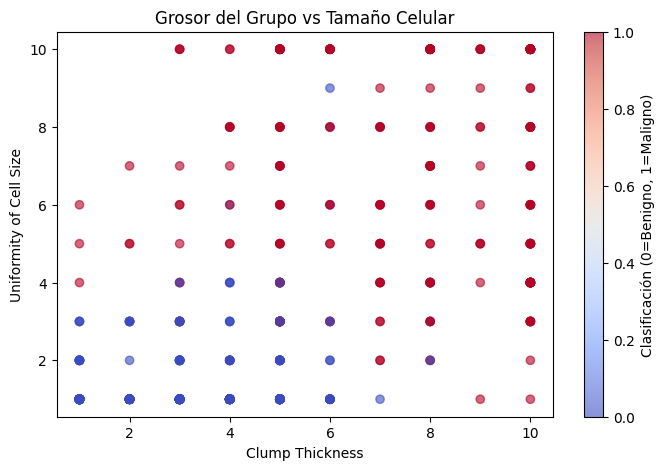

In [4]:
# ==============================================================================
# 4. NORMALIZACIÓN Y VISUALIZACIÓN
# ==============================================================================
X = df.drop('Class', axis=1).values
y = df['Class'].values

def featureNormalize(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1
    return (X - mu) / sigma

X_norm = featureNormalize(X)

print("\n¡MATRIZ X_norm CREADA! Forma:", X_norm.shape)

plt.figure(figsize=(8, 5))
plt.scatter(df['Clump_Thickness'], df['Uniformity_Cell_Size'], c=df['Class'], cmap='coolwarm', alpha=0.6)
plt.title('Grosor del Grupo vs Tamaño Celular')
plt.xlabel('Clump Thickness')
plt.ylabel('Uniformity of Cell Size')
plt.colorbar(label='Clasificación (0=Benigno, 1=Maligno)')
plt.show()